# COSMOS shear estimate contours

Reproduces the contour plot from `outputs/distillation/combined_white/combined_estimates_100.ipynb`, but in publication style: filled credible regions, distinct colour palettes for each method, clean typography.

Inputs are the precomputed combined-GMM Gaussian summaries (`mean`, `cov`) saved by the original notebook:
- `outputs/distillation/combined_white/combined_gmm_results.npz` — Flow + AE estimator.
- `outputs/papers/parametric_hst_whitened/combined_gmm_results.npz` — parametric Spergel estimator (the biased case).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import multivariate_normal

In [2]:
# Load precomputed combined-GMM Gaussian summaries
ae_path = '../distillation/combined_white/combined_gmm_results.npz'
sp_path = './parametric_hst_whitened/combined_gmm_results.npz'

ae_data = np.load(ae_path)
sp_data = np.load(sp_path)

ae_mean, ae_cov = ae_data['mean'], ae_data['cov']
sp_mean, sp_cov = sp_data['mean'], sp_data['cov']

g1_true, g2_true = -0.05, 0.05

print(f'Flow+AE: mean=({ae_mean[0]:+.5f}, {ae_mean[1]:+.5f})  σ=({np.sqrt(ae_cov[0,0]):.5f}, {np.sqrt(ae_cov[1,1]):.5f})')
print(f'Spergel: mean=({sp_mean[0]:+.5f}, {sp_mean[1]:+.5f})  σ=({np.sqrt(sp_cov[0,0]):.5f}, {np.sqrt(sp_cov[1,1]):.5f})')
print(f'Truth:   ({g1_true:+.5f}, {g2_true:+.5f})')

Flow+AE: mean=(-0.05468, +0.04876)  σ=(0.00176, 0.00164)
Spergel: mean=(-0.03750, +0.04341)  σ=(0.00121, 0.00122)
Truth:   (-0.05000, +0.05000)


In [3]:
def gaussian_contour_thresholds(mean, cov, levels, n_grid=400, margin=5):
    """Evaluate a 2D Gaussian on a grid and return density thresholds
    corresponding to highest-density credible-mass levels."""
    std = np.sqrt(np.diag(cov))
    g1 = np.linspace(mean[0] - margin*std[0], mean[0] + margin*std[0], n_grid)
    g2 = np.linspace(mean[1] - margin*std[1], mean[1] + margin*std[1], n_grid)
    G1, G2 = np.meshgrid(g1, g2)
    rv = multivariate_normal(mean=mean, cov=cov)
    density = rv.pdf(np.dstack([G1, G2]))
    # Convert credible-mass levels to density thresholds (highest-density regions)
    sorted_d = np.sort(density.ravel())[::-1]
    cumsum = np.cumsum(sorted_d)
    cumsum /= cumsum[-1]
    thresholds = []
    for lev in sorted(levels):  # ascending mass → ascending grid size → descending density
        idx = np.searchsorted(cumsum, lev)
        thresholds.append(sorted_d[min(idx, len(sorted_d) - 1)])
    return G1, G2, density, sorted(thresholds)  # thresholds ascending for matplotlib

In [25]:
# Evaluate both posteriors on a common grid (centred on the union of the two means)
levels = [0.68, 0.95, 0.997]   # 1σ, 2σ, 3σ credible mass
n_grid = 500

# Common axes spanning a region that comfortably encloses both posteriors and the truth
g1_lo, g1_hi = -0.07, -0.03
g2_lo, g2_hi =  0.03,  0.07
g1_arr = np.linspace(g1_lo, g1_hi, n_grid)
g2_arr = np.linspace(g2_lo, g2_hi, n_grid)
G1, G2 = np.meshgrid(g1_arr, g2_arr)
stack = np.dstack([G1, G2])

ae_density = multivariate_normal(mean=ae_mean, cov=ae_cov).pdf(stack)
sp_density = multivariate_normal(mean=sp_mean, cov=sp_cov).pdf(stack)

def hdr_thresholds(density, levels):
    sorted_d = np.sort(density.ravel())[::-1]
    cumsum = np.cumsum(sorted_d); cumsum /= cumsum[-1]
    return sorted([sorted_d[min(np.searchsorted(cumsum, lev), len(sorted_d) - 1)] for lev in levels])

ae_thr = hdr_thresholds(ae_density, levels)
sp_thr = hdr_thresholds(sp_density, levels)
print('AE+flow density thresholds (68/95/99.7%):', [f'{t:.2e}' for t in ae_thr])
print('Spergel density thresholds (68/95/99.7%):', [f'{t:.2e}' for t in sp_thr])

AE+flow density thresholds (68/95/99.7%): ['1.65e+02', '2.76e+03', '1.76e+04']
Spergel density thresholds (68/95/99.7%): ['3.23e+02', '5.39e+03', '3.46e+04']


/var/folders/9y/7z0g8qdn2bvc23npg8q10qxn7rzw1x/T/ipykernel_95533/778239391.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  oranges = cm.get_cmap('Oranges')
/var/folders/9y/7z0g8qdn2bvc23npg8q10qxn7rzw1x/T/ipykernel_95533/778239391.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  purples = cm.get_cmap('Purples')


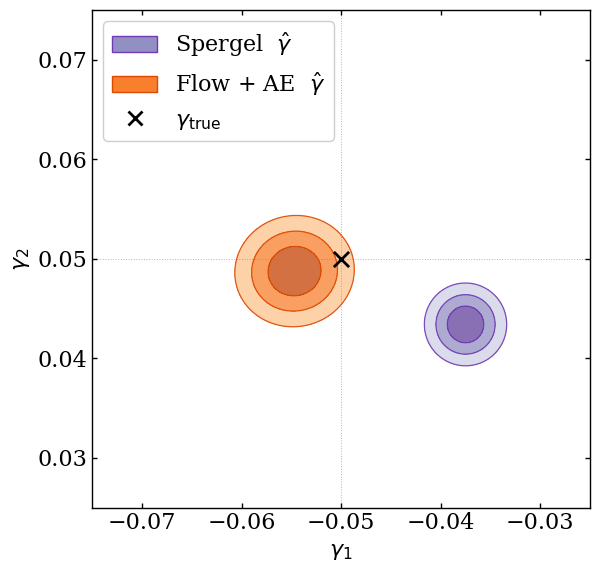

In [26]:
# Colour palettes — sequential, light-to-dark with method-distinct hue
oranges = cm.get_cmap('Oranges')
purples = cm.get_cmap('Purples')

# Three fill shades per palette (outer 3σ → inner 1σ)
ae_fill_colors  = [oranges(0.30), oranges(0.55), oranges(0.80)]
sp_fill_colors  = [purples(0.30), purples(0.55), purples(0.80)]
ae_edge = "#DD4904"   # deep orange for outline / mean marker
sp_edge = "#723AB6"   # deep purple for outline / mean marker

plt.rcParams.update({
    'font.size': 16,
    'font.family': 'serif',
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

fig, ax = plt.subplots(figsize=(7, 6))

# Filled contours: from outer (lowest density, 99.7%) to inner (highest, 68%)
# Spergel first (drawn underneath where they overlap)
ax.contourf(G1, G2, sp_density,
            levels=[sp_thr[0], sp_thr[1], sp_thr[2], sp_density.max()],
            colors=sp_fill_colors, alpha=0.75)
ax.contour(G1, G2, sp_density, levels=sp_thr,
           colors=[sp_edge], linewidths=0.9, alpha=0.9)

ax.contourf(G1, G2, ae_density,
            levels=[ae_thr[0], ae_thr[1], ae_thr[2], ae_density.max()],
            colors=ae_fill_colors, alpha=0.75)
ax.contour(G1, G2, ae_density, levels=ae_thr,
           colors=[ae_edge], linewidths=0.9, alpha=0.9)

# # Posterior means
# ax.scatter(sp_mean[0], sp_mean[1], marker='o', s=50, facecolor='white',
#            edgecolor=sp_edge, linewidth=1.5, zorder=5)
# ax.scatter(ae_mean[0], ae_mean[1], marker='o', s=50, facecolor='white',
#            edgecolor=ae_edge, linewidth=1.5, zorder=5)

# Ground truth
ax.scatter(g1_true, g2_true, marker='x', s=120, color='black', linewidth=2.0,
           label=r'$\gamma_{\rm true}$', zorder=6)

# Legend proxies — use middle fill colour for each method
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Patch(facecolor=sp_fill_colors[1], edgecolor=sp_edge, label=r'Spergel  $\hat{\gamma}$'),
    Patch(facecolor=ae_fill_colors[1], edgecolor=ae_edge, label=r'Flow + AE  $\hat{\gamma}$'),
    Line2D([], [], marker='x', color='black', linestyle='', markersize=10,
           markeredgewidth=2.0, label=r'$\gamma_{\rm true}$'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=True, framealpha=0.95)

# Reference axis lines at the truth
ax.axvline(g1_true, color='gray', linestyle=':', linewidth=0.7, alpha=0.6, zorder=1)
ax.axhline(g2_true, color='gray', linestyle=':', linewidth=0.7, alpha=0.6, zorder=1)

ax.set_xlim(g1_lo-.005, g1_hi+.005)
ax.set_ylim(g2_lo-.005, g2_hi+.005)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$\gamma_1$')
ax.set_ylabel(r'$\gamma_2$')

ax.set_xticks(np.arange(g1_lo, g1_hi, 0.01))
ax.set_yticks(np.arange(g2_lo, g2_hi, 0.01))

plt.tight_layout()
plt.savefig('cosmos_shear_estimates.pdf', bbox_inches='tight')
plt.savefig('cosmos_shear_estimates.png', dpi=200, bbox_inches='tight')
plt.show()

In [27]:
# Bias / variance summary printed alongside the figure
for name, mean, cov in [('Flow + AE', ae_mean, ae_cov), ('Spergel  ', sp_mean, sp_cov)]:
    bias_g1 = mean[0] - g1_true
    bias_g2 = mean[1] - g2_true
    sig_g1, sig_g2 = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
    print(f'{name}: bias = ({bias_g1:+.5f}, {bias_g2:+.5f})  →  '
          f'({bias_g1/sig_g1:+5.1f}σ_g1, {bias_g2/sig_g2:+5.1f}σ_g2)  '
          f'σ = ({sig_g1:.5f}, {sig_g2:.5f})')

Flow + AE: bias = (-0.00468, -0.00124)  →  ( -2.7σ_g1,  -0.8σ_g2)  σ = (0.00176, 0.00164)
Spergel  : bias = (+0.01250, -0.00659)  →  (+10.3σ_g1,  -5.4σ_g2)  σ = (0.00121, 0.00122)
